In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


=== 第六折：L1-Logistic ===
Confusion Matrix:
[[103  14]
 [  4   4]]
Accuracy = 0.8560
False Alarm Rate = 0.1197

=== 第六折：Linear Regression ===
Confusion Matrix
[[97 20]
 [ 3  5]]
ACC = 0.8160
FAR = 0.1709

=== 第六折：Random Forest ===
Confusion Matrix
[[112   5]
 [  3   5]]
ACC = 0.9360
FAR = 0.0427

=== 第六折：xgbcoost ===
Confusion Matrix:
[[114   3]
 [  8   0]]
ACC = 0.9120
FAR = 0.0256

=== 第六折：Decision Tree ===
Confusion Matrix:
[[83 34]
 [ 3  5]]
ACC = 0.7040
FAR = 0.2906

=== 第六折：SVC ===
Confusion Matrix:
[[104  13]
 [  8   0]]
ACC = 0.8320
FAR = 0.1111


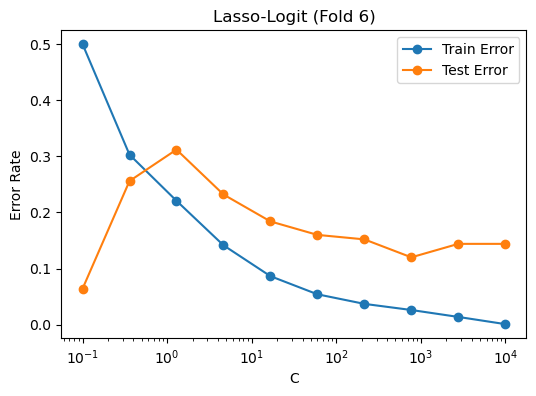

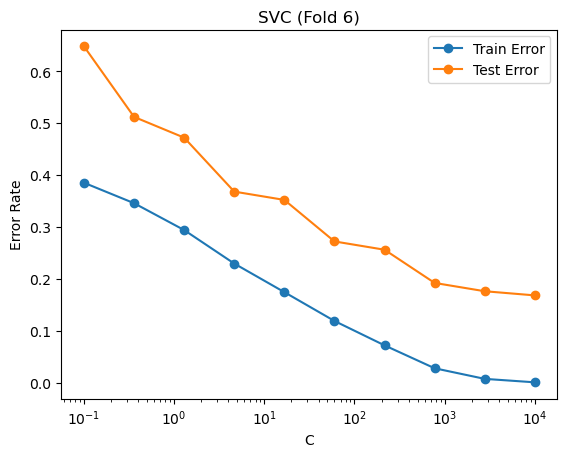

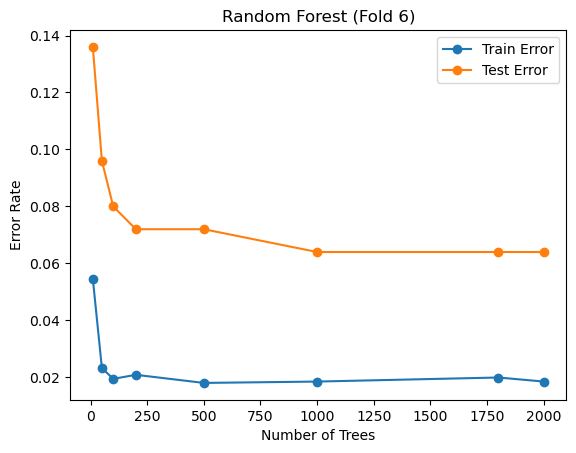

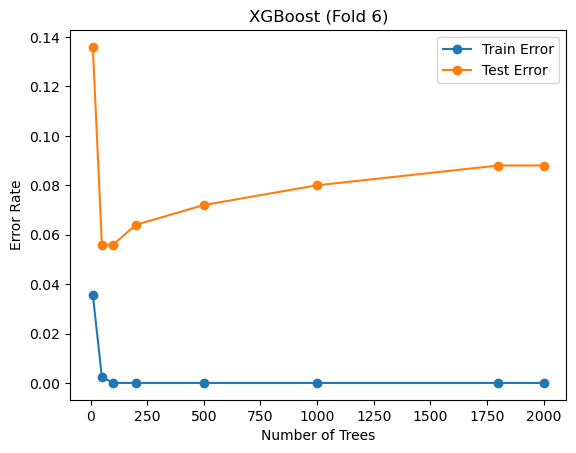

In [19]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imp = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    lr = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    lr.fit(X_tr_imp, y_tr)
    coef_series = pd.Series(lr.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef_series[coef_series != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]

    # 只對Lasso-Logit標準化
    X_tr_sel_scaled = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_sel_scaled = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # SMOTE（只在 train）
    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

    X_tr_sel_scaled_bal, y_tr_bal = smote.fit_resample(X_tr_sel_scaled, y_tr)
###
    train_errs_lor, test_errs_lor = [], []
    Cs = np.logspace(-3, 2, 10)
    for c in Cs:
        l1_lor = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=2000, random_state=42)
        l1_lor.fit(X_tr_sel_scaled_bal, y_tr_bal)
        
        y_train_pred_lor = l1_lor.predict(X_tr_sel_scaled_bal)
        y_pred_lor = l1_lor.predict(X_te_sel_scaled)
        cm_lr = confusion_matrix(y_te, y_pred_lor, labels=[0,1])
        tn, fp, fn, tp = cm_lr.ravel()
        acc_lor = accuracy_score(y_te, y_pred_lor)
        far_lor = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_lor.append(1-accuracy_score(y_tr_bal, y_train_pred_lor))
        test_errs_lor.append(1-accuracy_score(y_te, y_pred_lor))

    print("\n=== 第六折：L1-Logistic ===")
    print("Confusion Matrix:")
    print(cm_lr)
    print(f"Accuracy = {acc_lor:.4f}")
    print(f"False Alarm Rate = {far_lor:.4f}")
###
    lir = LinearRegression()
    lir.fit(X_tr_sel_scaled_bal, y_tr_bal)
    y_pred_lir_score = lir.predict(X_te_sel_scaled)
    y_pred_lir = (y_pred_lir_score >= 0.5).astype(int)
    cm_lir = confusion_matrix(y_te, y_pred_lir, labels=[0,1])
    tn, fp, fn, tp = cm_lir.ravel()
    acc_lir = accuracy_score(y_te, y_pred_lir)
    far_lir = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Linear Regression ===")
    print("Confusion Matrix")
    print(cm_lir)
    print(f"ACC = {acc_lir:.4f}")
    print(f"FAR = {far_lir:.4f}")
###
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sel, y_tr)

    train_errs_rf, test_errs_rf = [], []
    n_estimators_list = [10, 50, 100, 200, 500, 1000, 1800, 2000]
    for n in n_estimators_list:
        rfc = RandomForestClassifier(n_estimators=n, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
        rfc.fit(X_tr_bal, y_tr_bal)

        y_train_pred_rf = rfc.predict(X_tr_bal)
        y_pred_rf = rfc.predict(X_te_sel)
        cm_rf = confusion_matrix(y_te, y_pred_rf, labels=[0,1])
        tn, fp, fn, tp = cm_rf.ravel()
        acc_rf = accuracy_score(y_te, y_pred_rf)
        far_rf = fp/(fp+tn) if (fp+tn)>0 else np.nan
            
        train_errs_rf.append(1-accuracy_score(y_tr_bal, y_train_pred_rf))
        test_errs_rf.append(1-accuracy_score(y_te, y_pred_rf))

    print("\n=== 第六折：Random Forest ===")
    print("Confusion Matrix")
    print(cm_rf)
    print(f"ACC = {acc_rf:.4f}")
    print(f"FAR = {far_rf:.4f}")
###
    train_errs_xgbc, test_errs_xgbc = [], []
    for n in n_estimators_list:
        xgbc = XGBClassifier(objective='binary:logistic', n_estimators=n, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, eval_metric='logloss')
        xgbc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_xgbc = xgbc.predict(X_tr_bal)
        y_pred_xgbc = xgbc.predict(X_te_sel)
        cm_xgbc = confusion_matrix(y_te, y_pred_xgbc, labels=[0,1])
        tn, fp, fn, tp = cm_xgbc.ravel()
        acc_xgbc = accuracy_score(y_te, y_pred_xgbc)
        far_xgbc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_xgbc.append(1-accuracy_score(y_tr_bal, y_tr_pred_xgbc))
        test_errs_xgbc.append(1-accuracy_score(y_te, y_pred_xgbc))

    print("\n=== 第六折：xgbcoost ===")
    print("Confusion Matrix:")
    print(cm_xgbc)
    print(f"ACC = {acc_xgbc:.4f}")
    print(f"FAR = {far_xgbc:.4f}")
###
    dtc = DecisionTreeClassifier(criterion='log_loss', max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42)
    dtc.fit(X_tr_bal, y_tr_bal)

    y_pred_dtc = dtc.predict(X_te_sel)
    cm_dtc = confusion_matrix(y_te, y_pred_dtc, labels=[0,1])
    tn, fp, fn, tp = cm_dtc.ravel()
    acc_dtc = accuracy_score(y_te, y_pred_dtc)
    far_dtc = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Decision Tree ===")
    print("Confusion Matrix:")
    print(cm_dtc)
    print(f"ACC = {acc_dtc:.4f}")
    print(f"FAR = {far_dtc:.4f}")

    train_errs_svc, test_errs_svc = [], []
    Cs = np.logspace(-1, 4, 10)
    for c in Cs:
        svc = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
        svc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_svc = svc.predict(X_tr_bal)
        y_pred_svc = svc.predict(X_te_sel)
        cm_svc = confusion_matrix(y_te, y_pred_svc, labels=[0,1])
        tn, fp, fn, tp = cm_svc.ravel()
        acc_svc = accuracy_score(y_te, y_pred_svc)
        far_svc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_svc.append(1-accuracy_score(y_tr_bal, y_tr_pred_svc))
        test_errs_svc.append(1-accuracy_score(y_te, y_pred_svc))

    print("\n=== 第六折：SVC ===")
    print("Confusion Matrix:")
    print(cm_svc)
    print(f"ACC = {acc_svc:.4f}")
    print(f"FAR = {far_svc:.4f}")
    break

plt.figure(figsize=(6,4))
plt.plot(Cs, train_errs_lor, marker='o', label='Train Error')
plt.plot(Cs, test_errs_lor, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("Lasso-Logit (Fold 6)")
plt.legend()
plt.show()

plt.plot(Cs, train_errs_svc, marker='o', label='Train Error')
plt.plot(Cs, test_errs_svc, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("SVC (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_rf, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_rf, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("Random Forest (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_xgbc, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_xgbc, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("XGBoost (Fold 6)")
plt.legend()
plt.show()

In [12]:
n_estimators_list

[10, 50, 100, 200, 500, 1000, 1800, 2000]

---
---

## 在第6折, 以logit regression的MLE+梯度下降法計算x的$\hat{\beta}$, 並依照絕對值遞減排列

In [13]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    scaler = StandardScaler()
    X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr_imputed), columns=X_tr_imputed.columns, index=X_tr_imputed.index)
    X_te_std = pd.DataFrame(scaler.fit_transform(X_te_imputed), columns=X_te_imputed.columns, index=X_te_imputed.index)

    X_tr_sel = X_tr_std[selected]
    X_te_sel = X_te_std[selected]

    print(f'[L1-Logit] 篩到 {X_tr_sel.shape[1]} 個特徵')
    print(selected)

    # 以梯度下降（無正則）估計 Logit 係數
    # 目標：最小化平均負對數似然
    # p = sigmoid(Xb)，X 需含截距
    n, p = X_tr_sel.shape
    X_gd = np.hstack([np.ones((n, 1)), X_tr_sel])  # 加截距
    X_te_gd = np.hstack([np.ones((X_te_sel.shape[0], 1)), X_te_sel])
    beta = np.zeros(p+1)

    def _sigmoid(z):
        return 1.0/(1.0+np.exp(-z))

    # 超參數
    learning_r = 0.05
    max_iter = 500000
    tol = 1e-6
    loss_hist = []
    te_loss_hist = []
    # prev_loss = np.inf
    best_te_loss = np.inf
    best_beta = beta.copy()
    best_it = 0
    patience, noimp = 50, 0
    for it in range(1, max_iter+1):
        z = X_gd@beta
        z_te = X_te_gd @ beta
        
        p_hat = 1.0/(1.0+np.exp(-z))
        p_te_hat = 1.0/(1.0+np.exp(-z_te))

        loss = -np.mean(y_tr*np.log(p_hat)+(1-y_tr)*np.log(1-p_hat))
        te_loss = -np.mean(y_te*np.log(p_te_hat)+(1-y_te)*np.log(1-p_te_hat))

        grad = X_gd.T@(p_hat-y_tr)/n
        beta -= learning_r*grad
        loss_hist.append(loss)
        te_loss_hist.append(te_loss)

        if te_loss<best_te_loss-(1e-6):
            best_te_loss = te_loss
            best_beta = beta.copy()
            best_it = it
            noimp = 0
        else:
            noimp += 1
            if noimp >= patience:
                break
    beta = best_beta
    print(f'[EarlyStop] best_iter={best_it}, best_val_loss={best_te_loss:.6f}')            

        # if abs(prev_loss-loss)<1e-6:
        #     break
        # prev_loss = loss

    # print(f'[GD-Logit] 迭代次數: {it}, 最終 loss: {loss:.6f}')
    # print('[GD-Logit] 截距(beta0):', float(beta[0]))

    beta_df = pd.DataFrame({'feature': selected, 'beta_gd': beta[1:]}).sort_values('beta_gd', key=np.abs, ascending=False)
    pd.set_option('display.max_rows', None)


    break

[L1-Logit] 篩到 183 個特徵
['x1', 'x2', 'x3', 'x4', 'x5', 'x7', 'x13', 'x15', 'x16', 'x19', 'x22', 'x23', 'x24', 'x25', 'x29', 'x32', 'x33', 'x34', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x44', 'x46', 'x47', 'x49', 'x51', 'x52', 'x56', 'x60', 'x63', 'x64', 'x65', 'x66', 'x67', 'x69', 'x71', 'x72', 'x89', 'x91', 'x99', 'x116', 'x118', 'x122', 'x123', 'x127', 'x130', 'x134', 'x135', 'x136', 'x137', 'x138', 'x139', 'x140', 'x151', 'x152', 'x160', 'x161', 'x162', 'x163', 'x178', 'x181', 'x183', 'x184', 'x188', 'x189', 'x198', 'x201', 'x203', 'x204', 'x205', 'x206', 'x208', 'x224', 'x226', 'x251', 'x269', 'x271', 'x272', 'x273', 'x275', 'x290', 'x295', 'x296', 'x297', 'x298', 'x317', 'x324', 'x325', 'x333', 'x334', 'x337', 'x342', 'x344', 'x362', 'x364', 'x389', 'x407', 'x413', 'x414', 'x416', 'x417', 'x418', 'x419', 'x420', 'x421', 'x424', 'x426', 'x429', 'x430', 'x431', 'x432', 'x433', 'x434', 'x435', 'x436', 'x437', 'x438', 'x439', 'x440', 'x441', 'x443', 'x446', 'x454', 'x457', 'x4

    feature   beta_gd
32      x60  0.302111
49     x130  0.244036
181    x578 -0.161597
66     x184  0.156439
104    x417 -0.154423


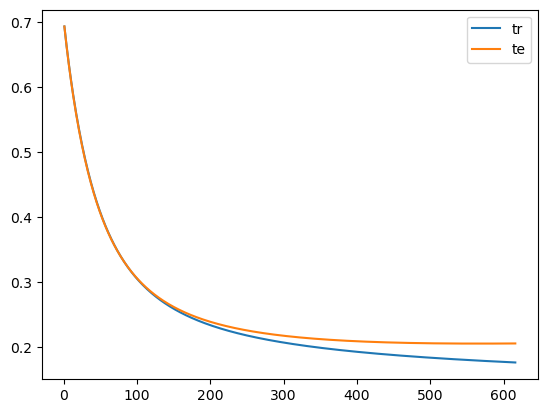

In [14]:
plt.plot(range(1, len(loss_hist)+1), loss_hist, label='tr')
plt.plot(range(1,len(te_loss_hist)+1), te_loss_hist, label='te')
plt.legend()
print(beta_df.head())

### LinAlgError: Singular matrix

In [15]:
# X_sm = sm.add_constant(X_tr_sel)
# res = sm.Logit(y_tr, X_sm).fit(disp=0)
# print(res.summary())  

---
---